In [8]:
import pandas as pd
import numpy as np
import  matplotlib.pyplot as plt
from statsmodels.graphics import correlation

from SCIKIT.Lesson9HyperparameterTuningwithGridsearchCV import maximum

np.random.seed(55)
n_samples=500
n_rooms=np.random.randint(1,10,n_samples)
n_area=np.random.randint(500,5000,n_samples)
n_bathrooms=np.random.randint(1,5,n_samples)
n_location_score=np.random.uniform(1,10,n_samples)
age=np.random.randint(0,50,n_samples)
n_garage=np.random.randint(0,2,n_samples)
noise=np.random.normal(0,3000,n_samples)


price=(
    n_area*120+n_bathrooms*25000-age*1500+n_rooms*38000+n_garage*20000+n_location_score*30000+noise

)
df=pd.DataFrame(
    {
        "n_area":n_area,
        "n_bathrooms":n_bathrooms,
        "n_rooms":n_rooms,
        "n_garage":n_garage,
        "n_location_score":n_location_score,
        "age":age,
        "price":price,



    }



)
df.head()



,n_area,n_bathrooms,n_rooms,n_garage,n_location_score,age,price
0,4913,2,8,1,6.737591,34,1.113221e+06
1,1999,3,9,1,9.238272,48,8.860114e+05
2,1206,4,6,0,4.250365,22,5.685830e+05
3,1581,2,8,0,2.973807,38,5.773215e+05
4,987,1,6,0,3.049259,17,4.364810e+05


In [12]:
print(df.shape)
print(df.describe())
print(df.isnull().sum())

(500, 7)
            n_area  n_bathrooms     n_rooms    n_garage  n_location_score  \
count   500.000000   500.000000  500.000000  500.000000        500.000000   
mean   2707.400000     2.462000    4.984000    0.518000          5.587260   
std    1304.769235     1.109513    2.655154    0.500176          2.557113   
min     501.000000     1.000000    1.000000    0.000000          1.020618   
25%    1620.500000     1.000000    3.000000    0.000000          3.548903   
50%    2662.500000     2.000000    5.000000    1.000000          5.610739   
75%    3794.750000     3.000000    7.000000    1.000000          7.755112   
max    4947.000000     4.000000    9.000000    1.000000          9.994095   

              age         price  
count  500.000000  5.000000e+02  
mean    25.072000  7.161621e+05  
std     14.374006  2.147113e+05  
min      0.000000  1.861725e+05  
25%     13.000000  5.640937e+05  
50%     25.000000  7.105815e+05  
75%     37.000000  8.649202e+05  
max     49.000000  1.2626

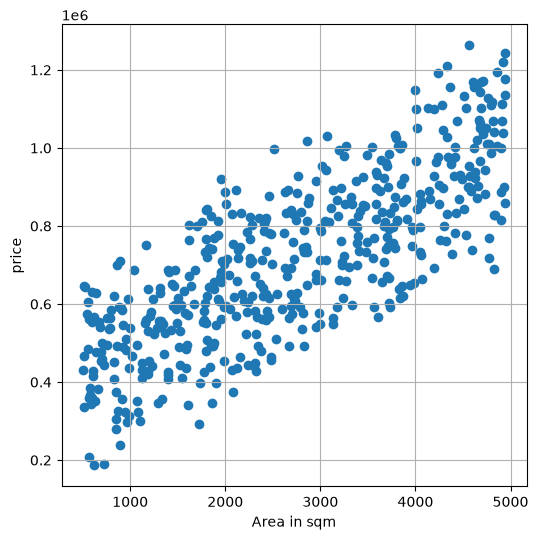

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(
    df["n_area"]
    ,
    df["price"]


)

plt.style.use('default')
plt.xlabel("Area in sqm")
plt.ylabel("price")
plt.grid()
plt.show()

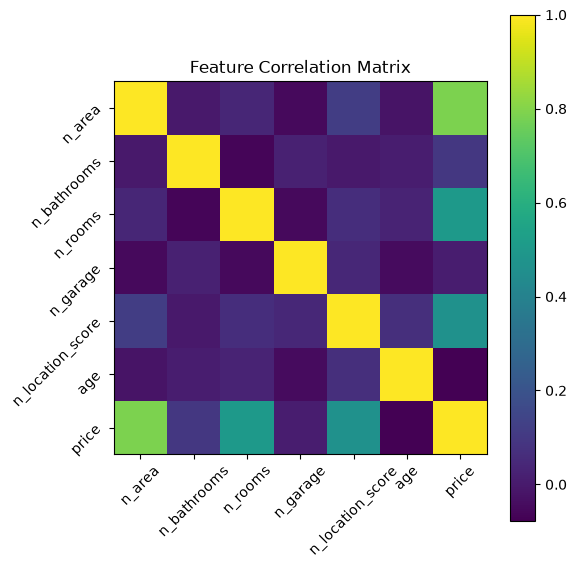

In [21]:
correlation=df.corr()
plt.figure(figsize=(6,6))
plt.imshow(correlation)
plt.colorbar()
plt.xticks(
    range(len(correlation)),
    correlation.columns
    ,
    rotation=45
)
plt.yticks(
     range(len(correlation)),
    correlation.columns,
    rotation=45

)
plt.title("Feature Correlation Matrix")
plt.tight_layout()

In [25]:
X=df.drop("price",axis=1)
y=df["price"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [29]:
print("training shape",X_train.shape)
print("Testing shape",X_test.shape)

training shape (400, 6)
Testing shape (400,)


In [35]:
from xgboost import XGBRFClassifier,XGBRegressor
model=XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42

)
model.fit(X_train,y_train)



,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


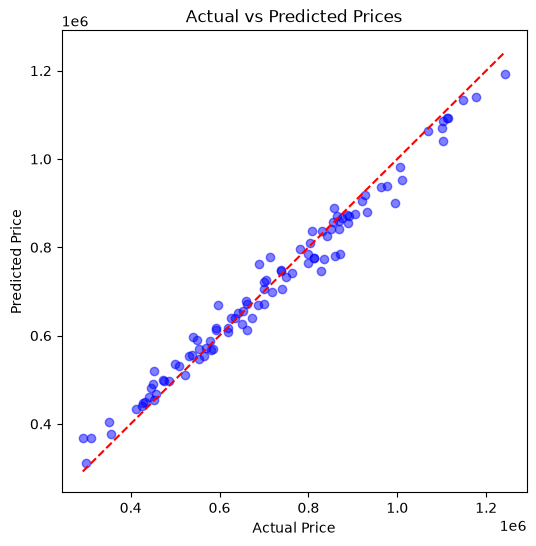

,Actual,Predicted,Errors
361,4.758190e+05,4.963543e+05,-20535.271384
73,5.007906e+05,5.366996e+05,-35908.993158
374,7.991703e+05,7.845354e+05,14634.854661
155,9.270099e+05,9.187156e+05,8294.293295
104,5.927494e+05,6.179673e+05,-25217.906548
...,...,...,...
347,8.518947e+05,8.417079e+05,10186.814835
86,5.930481e+05,6.125979e+05,-19549.880993
75,8.915684e+05,8.705515e+05,21016.859217
438,1.111023e+06,1.092140e+06,18882.148061


In [39]:
y_pred=model.predict(X_test)
comparison=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred,
    "Errors":y_test.values-y_pred

})
comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # reference line
plt.show()
comparison

In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 27,340.14
MSE: 1,197,555,733.53
RMSE: 34,605.72
R² Score: 0.9747


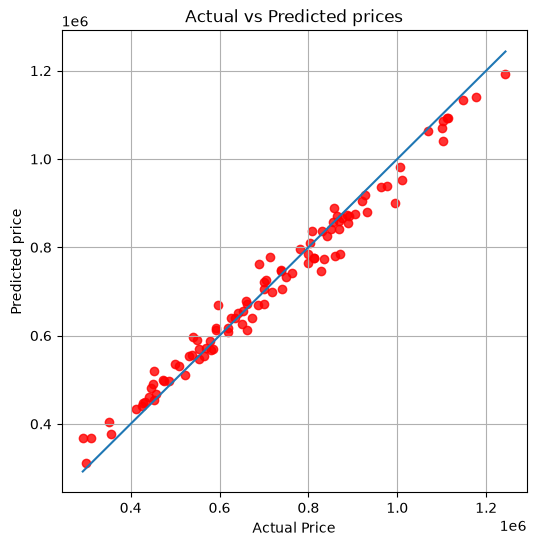

In [45]:
plt.figure(figsize=(6,6))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.8,
    color="red"
)
minimum=min(y_test.min()
,
            y_pred.min()
            )
maximum=max(y_test.max(),
            y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="-"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted prices")
plt.grid()
plt.show()

In [46]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

            Feature  Importance
0            n_area    0.382911
2           n_rooms    0.367585
4  n_location_score    0.137571
1       n_bathrooms    0.046588
5               age    0.039605
3          n_garage    0.025740


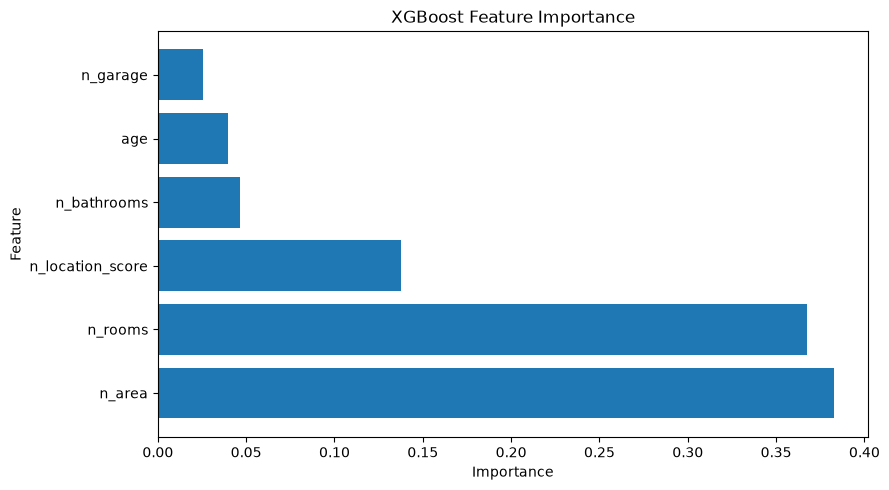

In [47]:
plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()

In [48]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train_final.shape)
print("Validation data:", X_val.shape)
print("Test data:", X_test.shape)

Training data: (320, 6)
Validation data: (80, 6)
Test data: (100, 6)


In [49]:
from xgboost import XGBRegressor

early_model = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    early_stopping_rounds=50,
    random_state=42
)

early_model.fit(
    X_train_final,
    y_train_final,
    eval_set=[
        (X_val, y_val)
    ],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [50]:
print("Best iteration:", early_model.best_iteration)

Best iteration: 1999


In [51]:
print("Best score:", early_model.best_score)

Best score: 26806.2912161609


In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_early = early_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_early)
mse = mean_squared_error(y_test, y_pred_early)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_early)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 19,360.42
RMSE: 24,292.86
R² Score: 0.9875
